In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image

print("PyTorch Version:", torch.__version__)
print("Torchvision Version:", torchvision.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch Version: 2.11.0+cu128
Torchvision Version: 0.26.0+cu128
CUDA Available: True
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
import os
from PIL import Image
import matplotlib.pyplot as plt

dataset_path = r"D:\cancer-detection\dataset\BreaKHis_v1"

image_paths = []
labels = []

for class_name in ["benign", "malignant"]:
    class_folder = os.path.join(dataset_path, class_name)

    for root, dirs, files in os.walk(class_folder):
        for file in files:
            if file.lower().endswith((".png", ".jpg", ".jpeg")):
                full_path = os.path.join(root, file)

                image_paths.append(full_path)
                labels.append(class_name)

print("Total Images:", len(image_paths))
print("Benign Images:", labels.count("benign"))
print("Malignant Images:", labels.count("malignant"))

Total Images: 7909
Benign Images: 2480
Malignant Images: 5429


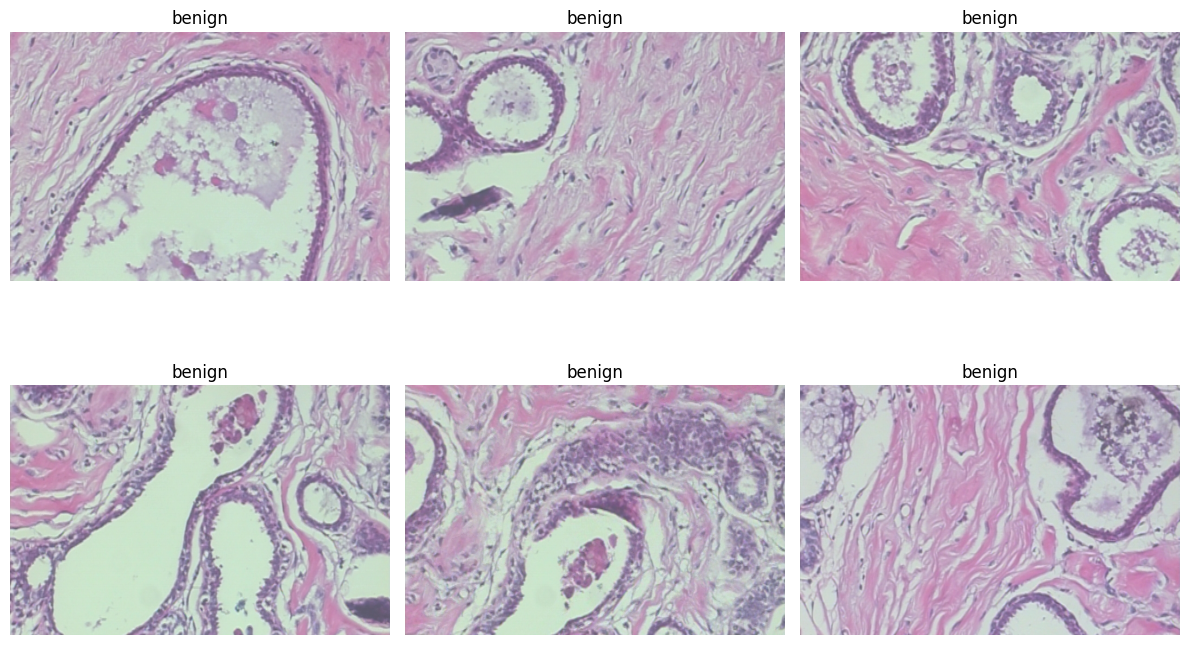

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(12,8))

for i, ax in enumerate(axes.flat):
    img = Image.open(image_paths[i]).convert("RGB")
    ax.imshow(img)
    ax.set_title(labels[i])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

In [5]:
class BreastCancerDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = 0 if self.labels[idx] == "benign" else 1

        return img, label

In [6]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
full_dataset = BreastCancerDataset(image_paths, labels, transform=transform)

print("Dataset Size:", len(full_dataset))

Dataset Size: 7909


In [8]:
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

print("Train Images:", len(train_dataset))
print("Test Images:", len(test_dataset))

Train Images: 6327
Test Images: 1582


In [9]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("DataLoader Ready")

DataLoader Ready


In [10]:
images, labels_batch = next(iter(train_loader))

print("Image Batch Shape:", images.shape)
print("Labels:", labels_batch)

Image Batch Shape: torch.Size([16, 3, 224, 224])
Labels: tensor([1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0])


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

Using Device: cuda


In [13]:
import os

path = r"C:\Users\yash1\.cache\torch\hub\checkpoints\resnet18-f37072fd.pth"

if os.path.exists(path):
    os.remove(path)
    print("Corrupted file deleted")
else:
    print("File not found")

File not found


In [14]:
model = models.resnet18(weights=None)

In [15]:
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

In [16]:
model = model.to(device)
print("Model Ready")

Model Ready


In [17]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [18]:
images, labels_batch = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print("Output Shape:", outputs.shape)

Output Shape: torch.Size([16, 2])


In [19]:
epochs = 3
best_accuracy = 0
train_losses = []
train_accuracies = []

In [20]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

model = models.resnet18(weights=None)   # or "DEFAULT" if pretrained download works
model.fc = nn.Linear(model.fc.in_features, 2)  # benign / malignant
model = model.to(device)

print("Model ready on:", next(model.parameters()).device)

Using: cuda
Model ready on: cuda:0


In [21]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    r"D:\cancer-detection\dataset",
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

print("Classes:", train_dataset.classes)
print("Images:", len(train_dataset))
print("Batches:", len(train_loader))

Classes: ['BreaKHis_v1']
Images: 7909
Batches: 248


In [22]:
import os

save_folder = r"D:\cancer-detection\models"
os.makedirs(save_folder, exist_ok=True)

save_path = os.path.join(save_folder, "best_model_v2.pth")

for epoch in range(epochs):
    print("Epoch started:", epoch + 1)

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    print(f"\nStarting Epoch {epoch+1}/{epochs}")

    for batch_idx, (images, labels_batch) in enumerate(train_loader):

        images = images.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels_batch.size(0)
        correct += (predicted == labels_batch).sum().item()

        if batch_idx % 20 == 0:
            print(f"Batch {batch_idx}/{len(train_loader)} running...")

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f} Accuracy: {epoch_acc:.2f}%")

    # Save best model
    if epoch_acc > best_accuracy:
        best_accuracy = epoch_acc
        torch.save(model.state_dict(), save_path)
        print("Best model saved!")

Epoch started: 1

Starting Epoch 1/3
Batch 0/248 running...
Batch 20/248 running...
Batch 40/248 running...
Batch 60/248 running...
Batch 80/248 running...
Batch 100/248 running...
Batch 120/248 running...
Batch 140/248 running...
Batch 160/248 running...
Batch 180/248 running...
Batch 200/248 running...
Batch 220/248 running...
Batch 240/248 running...
Epoch [1/3] Loss: 0.5455 Accuracy: 92.98%
Best model saved!
Epoch started: 2

Starting Epoch 2/3
Batch 0/248 running...
Batch 20/248 running...
Batch 40/248 running...
Batch 60/248 running...
Batch 80/248 running...
Batch 100/248 running...
Batch 120/248 running...
Batch 140/248 running...
Batch 160/248 running...
Batch 180/248 running...
Batch 200/248 running...
Batch 220/248 running...
Batch 240/248 running...
Epoch [2/3] Loss: 0.5459 Accuracy: 93.65%
Best model saved!
Epoch started: 3

Starting Epoch 3/3
Batch 0/248 running...
Batch 20/248 running...
Batch 40/248 running...
Batch 60/248 running...
Batch 80/248 running...
Batch 100/24

In [23]:
print(train_losses)

[0.5455304723112814, 0.5458737967475769, 0.5454094205652514]


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

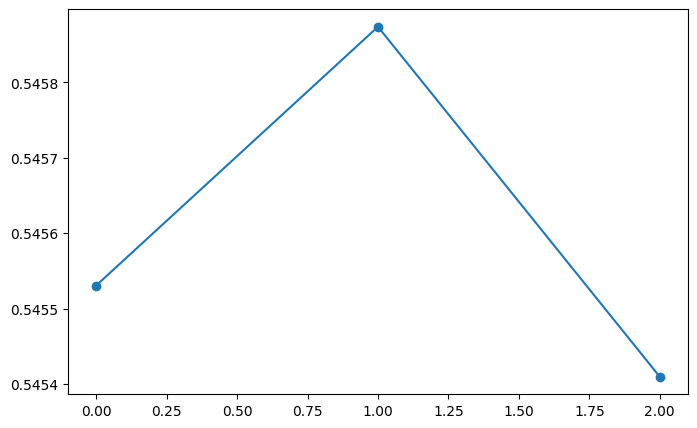

In [24]:
for epoch in range(epochs):
    plt.figure(figsize=(8,5))
plt.plot(train_losses, marker="o")
plt.show()

In [25]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels_batch in test_loader:
        
        images = images.to(device)
        labels_batch = labels_batch.to(device)
        
        outputs = model(images)
        
        _, predicted = torch.max(outputs, 1)
        
        total += labels_batch.size(0)
        correct += (predicted == labels_batch).sum().item()

test_accuracy = 100 * correct / total

print("Test Accuracy:", round(test_accuracy, 2), "%")

Test Accuracy: 70.35 %


In [26]:
print(train_losses)
print("Length:", len(train_losses))

[0.5455304723112814, 0.5458737967475769, 0.5454094205652514]
Length: 3


Losses: [0.5455304723112814, 0.5458737967475769, 0.5454094205652514]


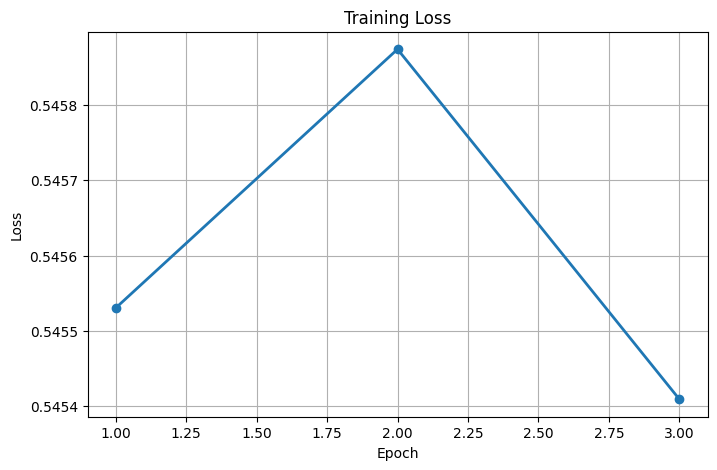

In [27]:
import matplotlib.pyplot as plt

print("Losses:", train_losses)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_losses)+1), train_losses, marker="o", linewidth=2)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

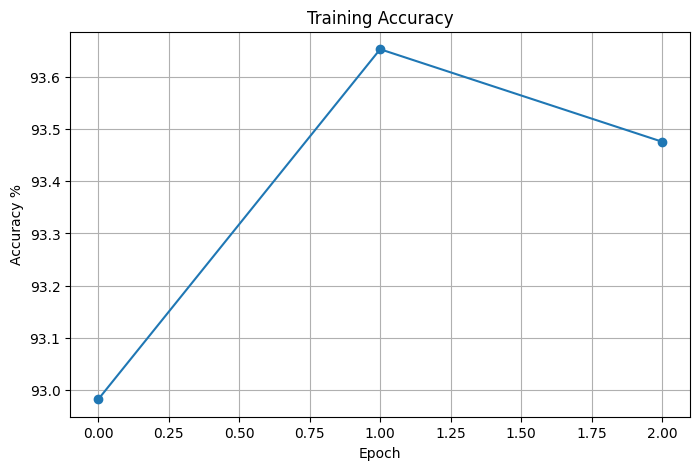

In [28]:
plt.figure(figsize=(8,5))
plt.plot(train_accuracies, marker="o")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy %")
plt.grid(True)
plt.show()

In [29]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

In [30]:
from PIL import Image
import matplotlib.pyplot as plt
import torch

classes = ["Benign", "Malignant"]

def predict_image(img_path):
    
    img = Image.open(img_path).convert("RGB")
    
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
    
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probs, 1)
    
    label = classes[predicted.item()]
    conf = confidence.item() * 100
    
    print("Prediction:", label)
    print("Confidence:", round(conf, 2), "%")

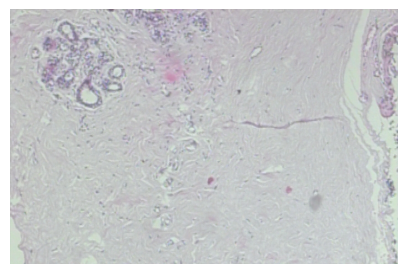

Prediction: Benign
Confidence: 70.97 %


In [31]:
predict_image(r"D:\cancer-detection\dataset\BreaKHis_v1\benign\SOB\adenosis\SOB_B_A_14-22549AB\40X\SOB_B_A-14-22549AB-40-003.png")

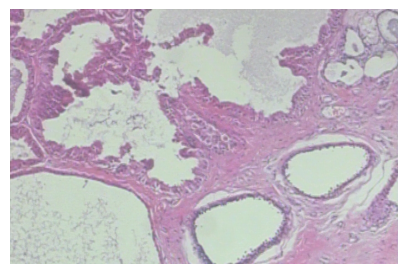

Prediction: Benign
Confidence: 50.45 %


In [39]:
predict_image(r"D:\cancer-detection\dataset\BreaKHis_v1\benign\SOB\adenosis\SOB_B_A_14-22549CD\40X\SOB_B_A-14-22549CD-40-030.png")

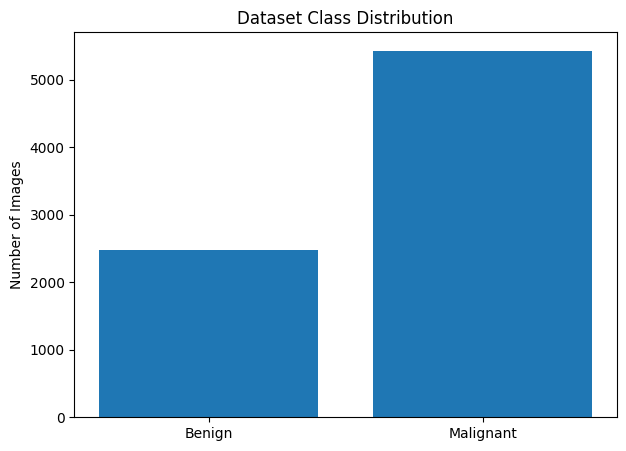

In [32]:
import matplotlib.pyplot as plt

benign_count = labels.count("benign")
malignant_count = labels.count("malignant")

plt.figure(figsize=(7,5))
plt.bar(["Benign", "Malignant"], [benign_count, malignant_count])
plt.title("Dataset Class Distribution")
plt.ylabel("Number of Images")
plt.show()

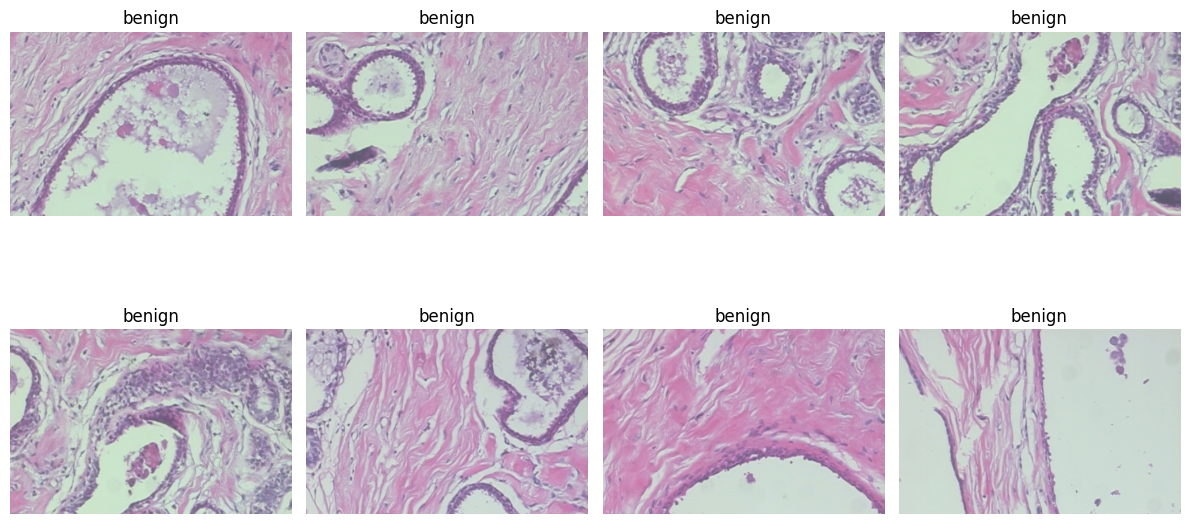

In [33]:
fig, axes = plt.subplots(2, 4, figsize=(12,7))

for i, ax in enumerate(axes.flat):
    img = Image.open(image_paths[i]).convert("RGB")
    ax.imshow(img)
    ax.set_title(labels[i])
    ax.axis("off")

plt.tight_layout()
plt.show()

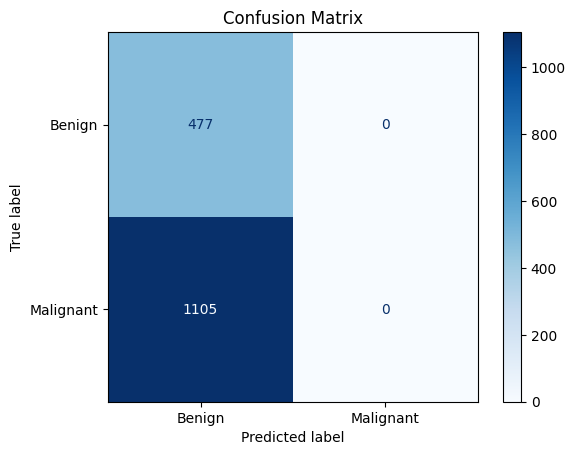

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels_batch in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels_batch.numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()